# Ropedia Academy — C1 · What is egocentric vision?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ChaoYue0307/ropedia-academy/blob/main/notebooks/C1.ipynb)

> **Visualizes two defining egocentric signals as heatmaps: the inter-frame ego-motion field and the center-bottom manipulation prior.**
>
> 把两种定义第一人称的信号画成热图：帧间自我运动场，以及中下部的操作先验。

This is the lesson's core example — **self-contained and runnable end to end**. It builds toy tensors, performs the lesson's key computation, and **visualizes the result with matplotlib** (the plot renders inline below the cell), so you learn the concept by executing and *seeing* it.

Colab's default runtime already includes `torch`, `numpy`, `networkx`, and `matplotlib`, so just press **Run all** — every cell goes green and a figure appears. Sizes are shrunk to run on CPU; swap in a real batch and the same code scales up.

🔗 Full lesson (with the interactive demo & key terms): https://chaoyue0307.github.io/ropedia-academy/lesson/C1

ego-motion magnitude (attention signal): 0.332


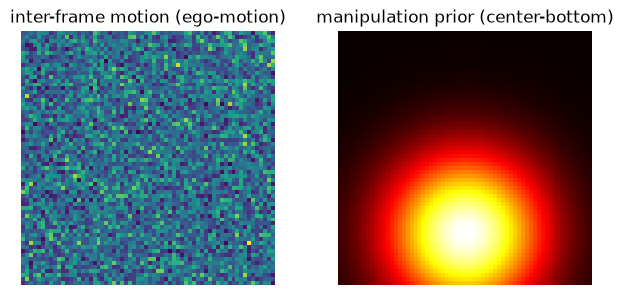

In [1]:
import torch, matplotlib.pyplot as plt
# First-person signals: ego-motion (camera moves with the head) + manipulation prior.

# ---------- INPUT: two consecutive frames (the camera shifted) ----------
H = W = 64
prev = torch.rand(3, H, W)
cur  = torch.roll(prev, shifts=(2, 3), dims=(1, 2))    # the camera moved with the head

# ---------- MODEL: inter-frame motion + a center-bottom manipulation prior ----------
ego = (cur - prev).abs().mean(0)                       # global motion field
yy, xx = torch.meshgrid(torch.linspace(0,1,H), torch.linspace(0,1,W), indexing='ij')
manip = torch.exp(-(((xx-0.5)**2)/0.1 + ((yy-0.8)**2)/0.1))   # peaks center-bottom

# ---------- OUTPUT: magnitude + the two signals as heatmaps ----------
print("ego-motion magnitude (attention signal):", round(ego.mean().item(), 3))
fig, ax = plt.subplots(1, 2, figsize=(7.5, 3.3))
ax[0].imshow(ego); ax[0].set_title("inter-frame motion (ego-motion)")
ax[1].imshow(manip, cmap='hot'); ax[1].set_title("manipulation prior (center-bottom)")
for a in ax: a.axis('off')
plt.show()

### Where to go next

- Swap the toy tensors for a real batch and watch the shapes flow through.
- Open the matching lesson for the math and an interactive figure: https://chaoyue0307.github.io/ropedia-academy/lesson/C1
- Browse every notebook: https://github.com/ChaoYue0307/ropedia-academy/tree/main/notebooks